# ☕ Classificador de Grãos de Café - README

## Descrição do Código
Este sistema utiliza **Processamento de Imagens Clássico** para classificar grãos de café.

### 1. Extração de Características (O Extrator Híbrido)
Em vez de usar redes neurais, extraímos vetores numéricos baseados em:
*   **Cor (Canais HSV):** Média, desvio padrão e assimetria (skewness) dos canais de Matiz, Saturação e Brilho. Isso captura o nível de torra e maturação.
*   **Textura (GLCM):** Analisamos a Matriz de Coocorrência para extrair Contraste, Homogeneidade e Energia, identificando a rugosidade do grão.

### 2. Classificação
Utilizamos o **Random Forest Classifier**, que recebe esses 14 atributos extraídos e aprende a distinguir as classes. O código inclui normalização (`StandardScaler`) para garantir que as diferenças de escala entre cor e textura não enviesem o modelo.

## Como Executar
1.  Garanta que seu Drive tem a pasta `Dataset` com subpastas para cada categoria.
2.  Execute as células de funções (`extrair_descritor_hibrido` e `carregar_dataset_cafe`).
3.  Execute a célula de Pipeline para treinar e avaliar.

In [50]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

### 1. FUNÇÃO DE EXTRAÇÃO DE CARACTERÍSTICAS

In [51]:
def extrair_descritor_hibrido(imagens):
    lista_descritores = []

    for img in imagens:
        # --- PARTE A: Cor (9 Atributos no espaço HSV) ---
        img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        h, s, v = cv2.split(img_hsv)

        cor_features = [
            np.mean(h), np.std(h), skew(h.ravel() + 1e-5),
            np.mean(s), np.std(s), skew(s.ravel() + 1e-5),
            np.mean(v), np.std(v), skew(v.ravel() + 1e-5)
        ]

        # --- PARTE B: Textura (5 Atributos na matriz GLCM) ---
        img_cinza = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        glcm = graycomatrix(img_cinza, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

        textura_features = [
            graycoprops(glcm, 'contrast')[0, 0],
            graycoprops(glcm, 'dissimilarity')[0, 0],
            graycoprops(glcm, 'homogeneity')[0, 0],
            graycoprops(glcm, 'energy')[0, 0],
            graycoprops(glcm, 'correlation')[0, 0]
        ]

        vetor_imagem = np.hstack((cor_features, textura_features))
        lista_descritores.append(vetor_imagem)

    return np.array(lista_descritores)

### 2. CARREGAMENTO DO DATASET

In [52]:
def carregar_dataset_cafe(diretorio_base):
    imagens, rotulos = [], []
    pastas_classes = [d for d in sorted(os.listdir(diretorio_base)) if os.path.isdir(os.path.join(diretorio_base, d))]

    for idx_classe, nome_classe in enumerate(pastas_classes):
        caminho_classe = os.path.join(diretorio_base, nome_classe)
        arquivos = os.listdir(caminho_classe)

        for arquivo in arquivos:
            caminho_arquivo = os.path.join(caminho_classe, arquivo)
            img = cv2.imread(caminho_arquivo)

            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (224, 224))
                imagens.append(img)
                rotulos.append(idx_classe)

    return np.array(imagens), np.array(rotulos), pastas_classes

### EXECUÇÃO DO PIPELINE

In [53]:
import os
import cv2
import numpy as np
from google.colab import drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

CAMINHO_RAIZ = '/content/drive/MyDrive/Dataset_Bean'

def carregar_dataset_dividido_flexivel(caminho_base):
    X_train, y_train, X_test, y_test = [], [], [], []

    if not os.path.exists(caminho_base):
        raise FileNotFoundError(f"O caminho {caminho_base} não foi encontrado.")

    conteudo = os.listdir(caminho_base)
    mapa_pastas = {n.lower(): n for n in conteudo}

    pasta_treino = mapa_pastas.get('train')
    pasta_teste = mapa_pastas.get('test')

    if not pasta_treino or not pasta_teste:
        raise ValueError(f"Pastas 'train'/'test' não encontradas em {caminho_base}. Conteúdo: {conteudo}")

    path_train_root = os.path.join(caminho_base, pasta_treino)
    path_test_root = os.path.join(caminho_base, pasta_teste)

    # Classes baseadas nas subpastas (Dark, Green, Light, Medium)
    classes = sorted([d for d in os.listdir(path_train_root) if os.path.isdir(os.path.join(path_train_root, d))])
    print(f"Classes detectadas: {classes}")

    def ler_imagens(diretorio_raiz, lista_X, lista_y):
        for idx, cls in enumerate(classes):
            pasta_classe = os.path.join(diretorio_raiz, cls)
            if not os.path.exists(pasta_classe): continue
            for img_nome in os.listdir(pasta_classe):
                if img_nome.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img = cv2.imread(os.path.join(pasta_classe, img_nome))
                    if img is not None:
                        # Converter BGR para RGB e redimensionar
                        img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (224, 224))
                        lista_X.append(img)
                        lista_y.append(idx)

    print("Carregando imagens de treino...")
    ler_imagens(path_train_root, X_train, y_train)
    print("Carregando imagens de teste...")
    ler_imagens(path_test_root, X_test, y_test)

    return (np.array(X_train), np.array(y_train)), (np.array(X_test), np.array(y_test)), classes

try:
    # Execução do Pipeline
    (X_train_img, y_train), (X_test_img, y_test), nomes_classes = carregar_dataset_dividido_flexivel(CAMINHO_RAIZ)

    if len(X_train_img) == 0:
        raise ValueError("Nenhuma imagem foi carregada. Verifique os arquivos nas pastas.")

    print(f"Extraindo características de {len(X_train_img)} imagens de treino...")
    X_train_feats = np.nan_to_num(extrair_descritor_hibrido(X_train_img))

    print(f"Extraindo características de {len(X_test_img)} imagens de teste...")
    X_test_feats = np.nan_to_num(extrair_descritor_hibrido(X_test_img))

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_feats)
    X_test_scaled = scaler.transform(X_test_feats)

    modelo = RandomForestClassifier(n_estimators=100, random_state=42)
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    print("Pipeline finalizado com sucesso!")
except Exception as e:
    print(f"Erro no processamento: {e}")

Classes detectadas: ['Dark', 'Green', 'Light', 'Medium']
Carregando imagens de treino...
Carregando imagens de teste...
Extraindo características de 1200 imagens de treino...
Extraindo características de 400 imagens de teste...
Pipeline finalizado com sucesso!


### RELATÓRIO OFICIAL DE SAÍDA (EXIGÊNCIA DO EDITAL)

In [54]:
acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n" + "="*50)
print("      RESULTADOS OBTIDOS NO CONJUNTO DE TESTE")
print(f"Acurácia: {acuracia:.4f}")
print(f"Precisão: {precisao:.4f}")
print(f"Recall:   {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("="*50)


      RESULTADOS OBTIDOS NO CONJUNTO DE TESTE
Acurácia: 1.0000
Precisão: 1.0000
Recall:   1.0000
F1-Score: 1.0000


### Relatório Final Detalhado
Este bloco consolida os dados de entrada (distribuição do dataset) e os resultados de saída do modelo.

In [55]:
import pandas as pd
import numpy as np

# Criando um resumo do dataset
total_treino = len(y_train)
total_teste = len(y_test)

print("=" * 50)
print("           RESUMO DO DATASET CARREGADO")
print(f"Caminho: {CAMINHO_RAIZ}")
print(f"Total de imagens de Treino: {total_treino}")
print(f"Total de imagens de Teste:  {total_teste}")
print("-" * 50)
print("Distribuição por Classe (Conjunto de Teste):")

# Contagem de amostras por classe no teste
unique, counts = np.unique(y_test, return_counts=True)
for cls_idx, count in zip(unique, counts):
    print(f"- {nomes_classes[cls_idx]}: {count} imagens")

print("=" * 50)
print("         DESEMPENHO DO CLASSIFICADOR")
print(f"Acurácia Final: {acuracia*100:.2f}%")
print(f"F1-Score:       {f1:.4f}")
print("=" * 50)

           RESUMO DO DATASET CARREGADO
Caminho: /content/drive/MyDrive/Dataset_Bean
Total de imagens de Treino: 1200
Total de imagens de Teste:  400
--------------------------------------------------
Distribuição por Classe (Conjunto de Teste):
- Dark: 100 imagens
- Green: 100 imagens
- Light: 100 imagens
- Medium: 100 imagens
         DESEMPENHO DO CLASSIFICADOR
Acurácia Final: 100.00%
F1-Score:       1.0000


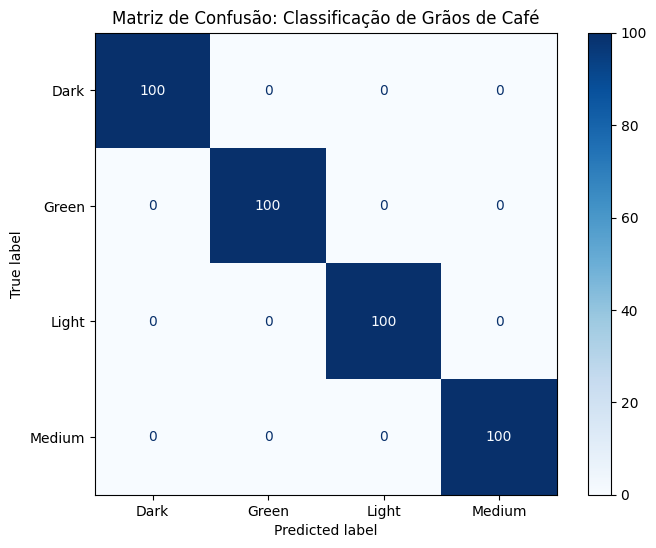

In [56]:
# 3. Matriz de Confusão Visual
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusão: Classificação de Grãos de Café')
plt.show()

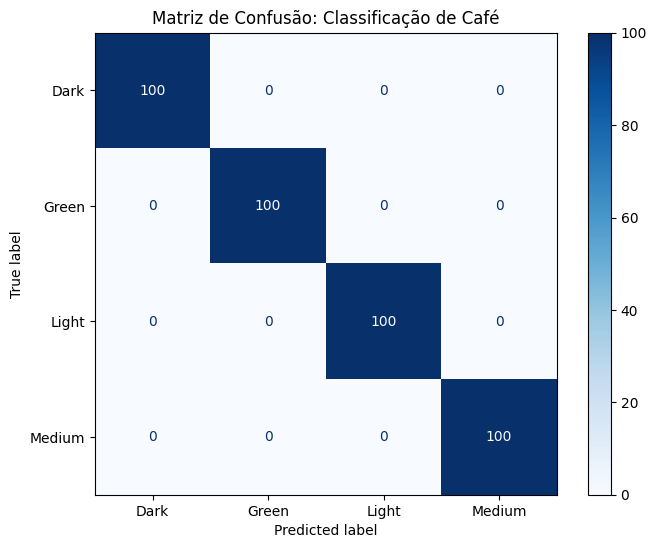

In [57]:
# 3. Matriz de Confusão Visual
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusão: Classificação de Café')
plt.show()